In [1]:
import os ; import sys
cipath = os.path.abspath(os.path.join(os.getcwd(),"..")) # address where the library is
sys.path.append(cipath+"/src")
import matplotlib.pyplot as plt

# Add magnetic field to an atom
Here you can see how to add magnetic field to an atom

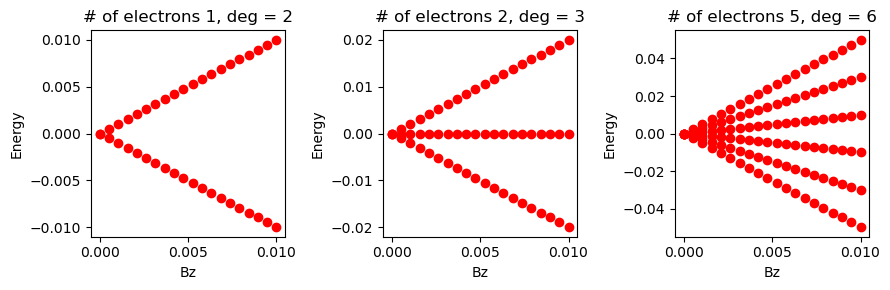

In [27]:
from tranci.atom import get_atom
import numpy as np

fig = plt.figure(figsize=[9,3])

nes = [1,2,5] # number of electrons
Bzs = np.linspace(0.,0.01,20) # magnetic fields
ine = 1
for ne in nes: # loop
    plt.subplot(1,len(nes),ine) ; ine += 1
    # generate an atom class for the system you want to compute
    Atom = get_atom(ne=ne) 
    # total Hamiltonian
    V = Atom.Operator["Coulomb"]
    CF = Atom.Operator["z2"] 
    H0 = 4*V + 0.4*CF # original Hamiltonian 
    # degeneracy without magnetic field
    deg = Atom.get_manifolds(H0).get_gs_multiplicity()
    deg = int(np.round(deg,1)) # degeneracy (as integer)
    for Bz in Bzs: # loop over operators
        H = H0 + Bz*(2*Atom.Operator["sz"] + Atom.Operator["lz"])
        M = Atom.get_manifolds(H) # get the manifolds object
        es = M.evals[0:deg] ; es = es - np.mean(es)
        plt.scatter(es*0 + Bz,es,c="red")
    plt.title("# of electrons "+str(ne)+", deg = "+str(deg))
    plt.xlabel("Bz") ; plt.ylabel("Energy")
plt.tight_layout()